# Forest Cover Type Classification

Luca Mongiello & Xiaojun Liang

Supervised multiclass classification of forest cover type (7 classes) on the UCI **Covertype** dataset (N = 581.012, p = 54), using Spark MLlib on a 2-node cluster (1 master + 1 worker), with data on **HDFS** and Spark running on **YARN**.

---

## Environment and required library versions

| Component   | Version |
|-------------|---------|
| Spark       | 4.1.2   |
| Hadoop      | 3.5.0   |
| Java        | 17      |
| Python      | 3.12.3  |
| pyspark     | 4.1.2   |
| pandas      | 3.0.3   |
| numpy       | 2.5.0   |
| matplotlib  | 3.11.0  |
| seaborn     | 0.13.2  |

## 1. Configuration

In [1]:
# --- Spark ---
SPARK_MASTER       = "yarn"
DEPLOY_MODE        = "client"
APP_NAME           = "covertype"
DRIVER_MEMORY      = "1g"        
EXECUTOR_INSTANCES = 1           
EXECUTOR_CORES     = 3
EXECUTOR_MEMORY    = "2500m"
EXECUTOR_OVERHEAD  = "512m"   
AM_MEMORY          = "512m"      
SHUFFLE_PARTITIONS = 12          

# --- HDFS ---
HDFS_DIR  = "hdfs:///user/vagrant/covtype"
HDFS_RAW  = HDFS_DIR + "/covtype.data.gz"
LOCAL_RAW = "/home/vagrant/covtype.data.gz"
DATA_URL  = ("https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz")

# --- Reproducibility and splits ---
SEED       = 42
TRAIN_FRAC = 0.8
TEST_FRAC  = 0.2

In [2]:
# --- Imports ---
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.stat import Correlation
from pyspark.ml.classification import (
    DecisionTreeClassifier, RandomForestClassifier,
    GBTClassifier, MultilayerPerceptronClassifier, OneVsRest,
)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

## 2. SparkSession

In [3]:
spark = (
    SparkSession.builder
    .appName(APP_NAME)
    .master(SPARK_MASTER)
    .config("spark.submit.deployMode",      DEPLOY_MODE)
    .config("spark.executor.instances",     EXECUTOR_INSTANCES)
    .config("spark.executor.cores",         EXECUTOR_CORES)
    .config("spark.executor.memory",        EXECUTOR_MEMORY)
    .config("spark.executor.memoryOverhead",EXECUTOR_OVERHEAD)
    .config("spark.yarn.am.memory",         AM_MEMORY)
    .config("spark.driver.memory",          DRIVER_MEMORY)
    .config("spark.sql.shuffle.partitions", SHUFFLE_PARTITIONS)
    .config("spark.ui.showConsoleProgress", "false")
    .config("spark.sql.debug.maxToStringFields", 100)
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/26 09:44:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/26 09:44:31 WARN Client: Neither spark.yarn.jars nor spark.yarn.archive is set, falling back to uploading libraries under SPARK_HOME.


## 3. Data acquisition

In [4]:
import os, subprocess, urllib.request

os.environ["HADOOP_ROOT_LOGGER"] = "ERROR,console"

def hdfs_exists(path: str) -> bool:
    return subprocess.run(["hdfs", "dfs", "-test", "-e", path]).returncode == 0

def sh(cmd: list):
    print("+", " ".join(cmd))
    subprocess.run(cmd, check=True)

sh(["hdfs", "dfs", "-mkdir", "-p", HDFS_DIR])

if hdfs_exists(HDFS_RAW):
    print("Already on HDFS:", HDFS_RAW)
else:
    if not os.path.exists(LOCAL_RAW):
        print("Downloading:", DATA_URL)
        urllib.request.urlretrieve(DATA_URL, LOCAL_RAW)
        print("Saved to:", LOCAL_RAW)
    sh(["hdfs", "dfs", "-put", "-f", LOCAL_RAW, HDFS_RAW])
    print("Uploaded to HDFS:", HDFS_RAW)

sh(["hdfs", "dfs", "-ls", HDFS_DIR])

+ hdfs dfs -mkdir -p hdfs:///user/vagrant/covtype
Already on HDFS: hdfs:///user/vagrant/covtype/covtype.data.gz
+ hdfs dfs -ls hdfs:///user/vagrant/covtype
Found 1 items
-rw-r--r--   1 vagrant supergroup   11240707 2026-06-24 11:36 hdfs:///user/vagrant/covtype/covtype.data.gz


## 4. Schema definition and data loading

In [5]:
# --- Column groups ---
QUANTITATIVE = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points",
]                                                          # 10 quantitative
WILDERNESS = [f"Wilderness_Area_{i}" for i in range(4)]    # 4 binary
SOIL       = [f"Soil_Type_{i}"      for i in range(40)]    # 40 binary
LABEL      = "Cover_Type"                                  # target (1..7)

FEATURE_COLS = QUANTITATIVE + WILDERNESS + SOIL
ALL_COLS     = FEATURE_COLS + [LABEL]

schema = StructType([
    StructField(name, IntegerType()) for name in ALL_COLS
])

In [6]:
df_raw = (
    spark.read
    .schema(schema)             
    .option("header", "false")
    .csv(HDFS_RAW)
)

df = df_raw.repartition(SHUFFLE_PARTITIONS).cache()

n_rows = df.count()

In [7]:
df.printSchema()
df.select(QUANTITATIVE + [LABEL]).limit(5).toPandas()

root
 |-- Elevation: integer (nullable = true)
 |-- Aspect: integer (nullable = true)
 |-- Slope: integer (nullable = true)
 |-- Horizontal_Distance_To_Hydrology: integer (nullable = true)
 |-- Vertical_Distance_To_Hydrology: integer (nullable = true)
 |-- Horizontal_Distance_To_Roadways: integer (nullable = true)
 |-- Hillshade_9am: integer (nullable = true)
 |-- Hillshade_Noon: integer (nullable = true)
 |-- Hillshade_3pm: integer (nullable = true)
 |-- Horizontal_Distance_To_Fire_Points: integer (nullable = true)
 |-- Wilderness_Area_0: integer (nullable = true)
 |-- Wilderness_Area_1: integer (nullable = true)
 |-- Wilderness_Area_2: integer (nullable = true)
 |-- Wilderness_Area_3: integer (nullable = true)
 |-- Soil_Type_0: integer (nullable = true)
 |-- Soil_Type_1: integer (nullable = true)
 |-- Soil_Type_2: integer (nullable = true)
 |-- Soil_Type_3: integer (nullable = true)
 |-- Soil_Type_4: integer (nullable = true)
 |-- Soil_Type_5: integer (nullable = true)
 |-- Soil_Type

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type
0,2773,44,14,90,21,1409,222,208,117,2219,2
1,3235,179,10,450,130,450,225,246,154,631,1
2,2894,89,11,124,21,3303,236,223,117,4696,2
3,3005,352,13,153,25,4290,196,217,158,854,2
4,3285,326,15,524,147,3818,182,222,179,2106,1


## 5. Exploratory Data Analysis

### 5.1 Class distribution and imbalance ratio

The target is strongly imbalanced. We quantify the imbalance ratio as $N_{max}/N_{min}$ over the full dataset.

 Cover_Type  count       pct
          1 211840 36.460521
          2 283301 48.759922
          3  35754  6.153746
          4   2747  0.472796
          5   9493  1.633873
          6  17367  2.989095
          7  20510  3.530048

Imbalance ratio (max/min): 103.1 : 1


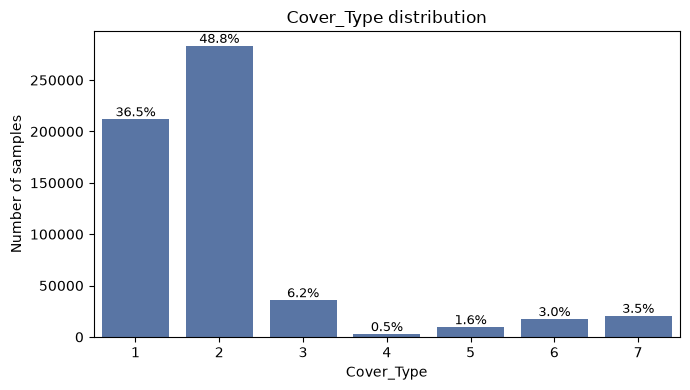

In [8]:
class_counts = (
    df.groupBy(LABEL).count()
      .orderBy(LABEL)
      .toPandas()
)
class_counts["pct"] = 100 * class_counts["count"] / class_counts["count"].sum()

imbalance_ratio = class_counts["count"].max() / class_counts["count"].min()
print(class_counts.to_string(index=False))
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.1f} : 1")

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=class_counts, x=LABEL, y="count", ax=ax, color="#4C72B0")
ax.set_title(f"Cover_Type distribution")
ax.set_xlabel("Cover_Type")
ax.set_ylabel("Number of samples")
for i, row in class_counts.iterrows():
    ax.text(i, row["count"], f"{row['pct']:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### 5.2 Global descriptive statistics

In [9]:
global_stats = (
    df.select(QUANTITATIVE)
      .describe()
      .toPandas()
      .set_index("summary")
      .T
)

global_stats = global_stats.astype(float).round(2)
global_stats

summary,count,mean,stddev,min,max
Elevation,581012.0,2959.37,279.98,1859.0,3858.0
Aspect,581012.0,155.66,111.91,0.0,360.0
Slope,581012.0,14.10,7.49,0.0,66.0
Horizontal_Distance_To_Hydrology,581012.0,269.43,212.55,0.0,1397.0
Vertical_Distance_To_Hydrology,581012.0,46.42,58.30,-173.0,601.0
Horizontal_Distance_To_Roadways,581012.0,2350.15,1559.25,0.0,7117.0
Hillshade_9am,581012.0,212.15,26.77,0.0,254.0
Hillshade_Noon,581012.0,223.32,19.77,0.0,254.0
Hillshade_3pm,581012.0,142.53,38.27,0.0,254.0
Horizontal_Distance_To_Fire_Points,581012.0,1980.29,1324.20,0.0,7173.0


### 5.3 Per-class statistics

We focus on `Elevation`, the most
discriminative feature according to Blackard & Dean (1999) and the feature-importance
analysis of Tavakol Sadrabadi & Innocente (2023): mean elevation separates several classes.

In [10]:
per_class_mean = (
    df.groupBy(LABEL)
      .agg(*[F.round(F.mean(c), 1).alias(c) for c in QUANTITATIVE])
      .orderBy(LABEL)
      .toPandas()
)

per_class_mean

,Cover_Type,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points
0,1,3128.6,156.1,13.1,270.6,42.2,2614.8,212.0,223.4,143.9,2009.3
1,2,2920.9,152.1,13.6,279.9,45.9,2429.5,213.8,225.3,143.0,2168.2
2,3,2394.5,176.4,20.8,210.3,62.4,943.9,201.9,215.8,140.4,911.0
3,4,2223.9,137.1,18.5,106.9,41.2,914.2,228.3,217.0,111.4,859.1
4,5,2787.4,139.3,16.6,212.4,50.6,1349.8,223.5,219.0,121.9,1577.7
5,6,2419.2,180.5,19.0,159.9,45.4,1037.2,192.8,209.8,148.3,1055.4
6,7,3361.9,153.2,14.3,357.0,69.5,2738.3,217.0,221.7,134.9,2070.0


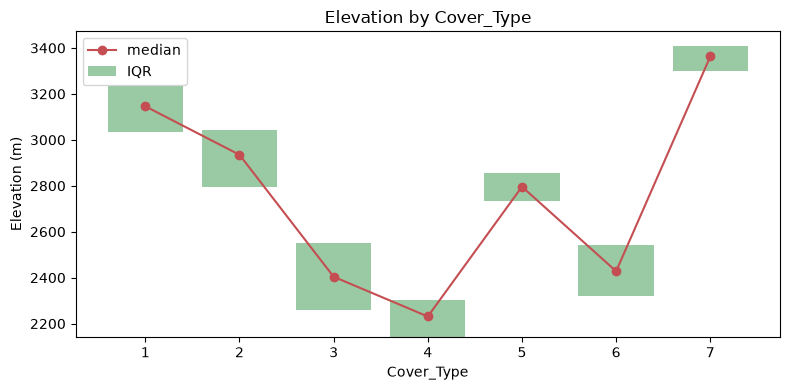

In [11]:
elev_by_class = (
    df.groupBy(LABEL)
      .agg(
          F.expr("percentile_approx(Elevation, 0.25)").alias("q1"),
          F.expr("percentile_approx(Elevation, 0.5)").alias("median"),
          F.expr("percentile_approx(Elevation, 0.75)").alias("q3"),
      )
      .orderBy(LABEL)
      .toPandas()
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(elev_by_class[LABEL], 
       elev_by_class["q3"] - elev_by_class["q1"],
       bottom=elev_by_class["q1"], 
       color="#55A868", 
       alpha=0.6, 
       label="IQR")
ax.plot(elev_by_class[LABEL], elev_by_class["median"], "o-", color="#C44E52", label="median")
ax.set_title("Elevation by Cover_Type")
ax.set_xlabel("Cover_Type")
ax.set_ylabel("Elevation (m)")
ax.legend()
plt.tight_layout()
plt.show()

### 5.4 Correlation of quantitative features

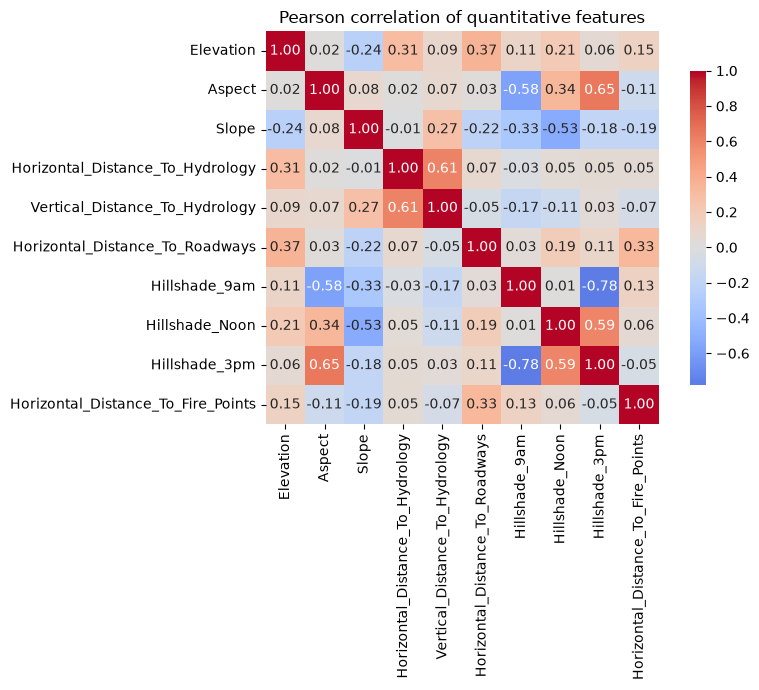

In [12]:
assembler = VectorAssembler(inputCols=QUANTITATIVE, outputCol="_quant_vec")
vec_df = assembler.transform(df.select(QUANTITATIVE))
corr_matrix = Correlation.corr(vec_df, "_quant_vec", "pearson").head()[0].toArray()

corr_pd = pd.DataFrame(corr_matrix, index=QUANTITATIVE, columns=QUANTITATIVE)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_pd, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Pearson correlation of quantitative features")
plt.tight_layout()
plt.show()

## 6. Preprocessing

In [13]:
LABEL_IDX = "label"
df_ml = df.withColumn(LABEL_IDX, F.col(LABEL) - 1)

assembler_feat = VectorAssembler(inputCols=FEATURE_COLS, outputCol="features")
df_ml = (
    assembler_feat.transform(df_ml)
    .select("features", LABEL_IDX)
    .withColumn("_id", F.monotonically_increasing_id())
    .cache()
)

label_range = df_ml.agg(F.min(LABEL_IDX), F.max(LABEL_IDX)).first()
print(f"Label range after remap: {label_range[0]}..{label_range[1]}")

df.unpersist();

Label range after remap: 0..6


In [14]:
fractions = {c: TRAIN_FRAC for c in range(7)}
train_df = df_ml.sampleBy(LABEL_IDX, fractions=fractions, seed=SEED).cache()
test_df  = df_ml.join(train_df.select("_id"), on="_id", how="left_anti").cache()

print(f"Train rows: {train_df.count():,}")
print(f"Test  rows: {test_df.count():,}")

print("\nClass proportions (train vs test):")
train_dist = train_df.groupBy(LABEL_IDX).count().orderBy(LABEL_IDX).toPandas()
test_dist  = test_df.groupBy(LABEL_IDX).count().orderBy(LABEL_IDX).toPandas()
train_dist["train_pct"] = 100 * train_dist["count"] / train_dist["count"].sum()
test_dist["test_pct"]   = 100 * test_dist["count"]  / test_dist["count"].sum()
comparison = train_dist[[LABEL_IDX, "train_pct"]].merge(test_dist[[LABEL_IDX, "test_pct"]], on=LABEL_IDX)
print(comparison.round(2).to_string(index=False))

Train rows: 465,178
Test  rows: 115,834

Class proportions (train vs test):
 label  train_pct  test_pct
     0      36.50     36.31
     1      48.74     48.85
     2       6.15      6.18
     3       0.47      0.48
     4       1.64      1.63
     5       2.99      2.98
     6       3.52      3.57


In [15]:
train_class_counts = (train_df.groupBy(LABEL_IDX).count().orderBy(LABEL_IDX).toPandas())
min_count = int(train_class_counts["count"].min())
print(f"Smallest training class: {min_count:,} rows")

undersample_fractions = {
    int(row[LABEL_IDX]): min(1.0, min_count / row["count"])
    for _, row in train_class_counts.iterrows()
}
train_bal = train_df.sampleBy(LABEL_IDX, fractions=undersample_fractions, seed=SEED).cache()

print(f"\nBalanced training rows: {train_bal.count():,}")
print("Balanced training distribution:")
print(train_bal.groupBy(LABEL_IDX).count().orderBy(LABEL_IDX).toPandas().to_string(index=False))

df_ml.unpersist();

Smallest training class: 2,192 rows

Balanced training rows: 15,360
Balanced training distribution:
 label  count
     0   2163
     1   2229
     2   2188
     3   2192
     4   2188
     5   2158
     6   2242


## 7. Models

In [ ]:
RESULTS = {}

_eval_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
_eval_f1  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
CLASSES = [f"C{i+1}" for i in range(7)]

def evaluate(name, model, test, train_time):
    preds = model.transform(test).select("label", "prediction")
    acc = _eval_acc.evaluate(preds)
    f1w = _eval_f1.evaluate(preds)

    cm_long = preds.groupBy("label", "prediction").count().toPandas()
    cm = (cm_long.pivot(index="label", columns="prediction", values="count").reindex(index=range(7), columns=range(7)).fillna(0).astype(int))
    cm_v = cm.values.astype(float)

    tp = np.diag(cm_v)
    fp = cm_v.sum(axis=0) - tp
    fn = cm_v.sum(axis=1) - tp
    prec = np.divide(tp, tp + fp, out=np.zeros(7), where=(tp + fp) > 0)
    rec  = np.divide(tp, tp + fn, out=np.zeros(7), where=(tp + fn) > 0)
    f1c  = np.divide(2 * prec * rec, prec + rec, out=np.zeros(7), where=(prec + rec) > 0)
    per_class = pd.DataFrame(
        {"precision": prec.round(3), "recall": rec.round(3), "f1": f1c.round(3)},
        index=CLASSES,
    )

    RESULTS[name] = {"accuracy": acc, "weighted_f1": f1w, "train_time_s": train_time, "per_class": per_class, "cm": cm}

    print(f"{name}:  accuracy={acc:.4f}   weighted_F1={f1w:.4f}   train_time={train_time:.1f}s\n")
    print(per_class.to_string())

    cm_norm = cm_v / cm_v.sum(axis=1, keepdims=True).clip(min=1)
    _, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title(f"{name} — normalized confusion matrix (row = true class)")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout(); plt.show()
    return RESULTS[name]

def run_model(name, estimator, train, test):
    start = time.time()
    model = estimator.fit(train)
    return evaluate(name, model, test, time.time() - start)

Decision Tree (balanced):  accuracy=0.6647   weighted_F1=0.6776   train_time=2.7s

    precision  recall     f1
C1      0.687   0.662  0.674
C2      0.781   0.616  0.689
C3      0.755   0.753  0.754
C4      0.550   0.928  0.691
C5      0.192   0.931  0.318
C6      0.490   0.800  0.608
C7      0.498   0.941  0.651


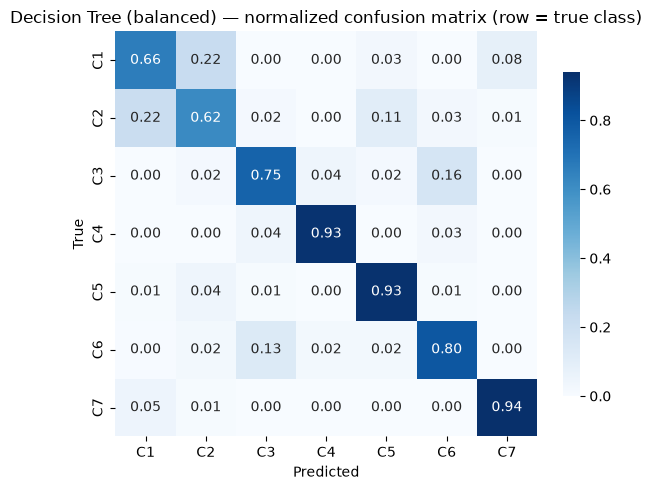

In [17]:
dt = DecisionTreeClassifier(labelCol="label", featuresCol="features", maxDepth=15, seed=SEED)
_ = run_model("Decision Tree (balanced)", dt, train_bal, test_df)

Random Forest (balanced):  accuracy=0.6875   weighted_F1=0.7065   train_time=9.0s

    precision  recall     f1
C1      0.732   0.720  0.726
C2      0.839   0.615  0.710
C3      0.781   0.746  0.763
C4      0.436   0.968  0.601
C5      0.166   0.956  0.283
C6      0.476   0.845  0.609
C7      0.497   0.953  0.654


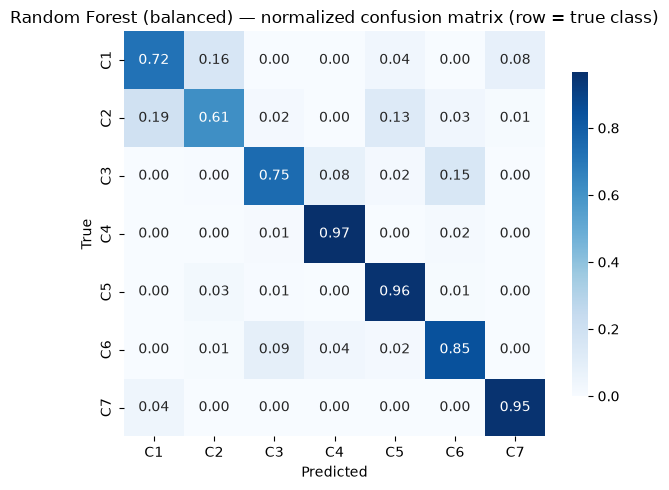

In [18]:
rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=50, maxDepth=15, seed=SEED)
_ = run_model("Random Forest (balanced)", rf, train_bal, test_df)

GBT (balanced):  accuracy=0.6181   weighted_F1=0.6442   train_time=42.1s

    precision  recall     f1
C1      0.686   0.687  0.687
C2      0.819   0.513  0.631
C3      0.736   0.682  0.708
C4      0.400   0.964  0.565
C5      0.118   0.926  0.209
C6      0.406   0.764  0.531
C7      0.432   0.938  0.592


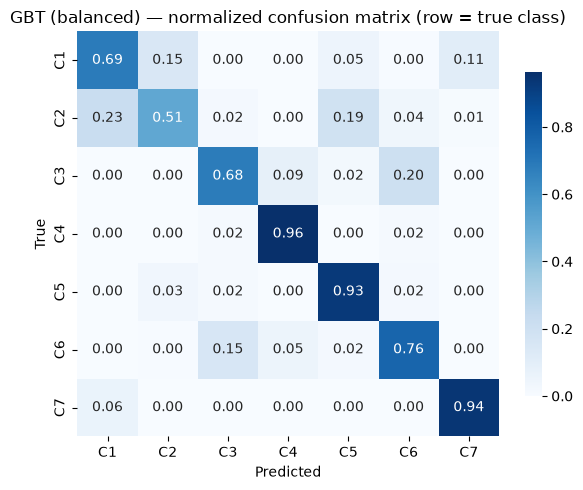

In [19]:
gbt = GBTClassifier(labelCol="label", featuresCol="features", maxIter=20, maxDepth=5, seed=SEED)
ovr_gbt = OneVsRest(classifier=gbt, labelCol="label", featuresCol="features")
_ = run_model("GBT (balanced)", ovr_gbt, train_bal, test_df)

MLP (balanced):  accuracy=0.6635   weighted_F1=0.6812   train_time=7.0s

    precision  recall     f1
C1      0.704   0.690  0.697
C2      0.808   0.606  0.693
C3      0.740   0.684  0.710
C4      0.379   0.923  0.537
C5      0.170   0.915  0.287
C6      0.429   0.724  0.539
C7      0.476   0.947  0.633


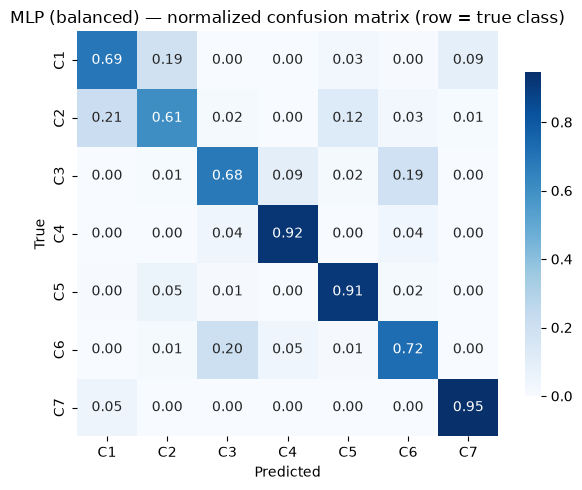

In [20]:
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withMean=True, withStd=True)
mlp = MultilayerPerceptronClassifier(labelCol="label", 
                                     featuresCol="scaledFeatures",
                                     layers=[len(FEATURE_COLS), 32, 7],
                                     maxIter=100, 
                                     seed=SEED)
mlp_pipeline = Pipeline(stages=[scaler, mlp])
_ = run_model("MLP (balanced)", mlp_pipeline, train_bal, test_df)

## 8. Hyperparameter tuning

In [21]:
CV_FOLDS = 3

def tune_model(name, estimator, param_grid, train, test):
    cv = CrossValidator(
        estimator=estimator,
        estimatorParamMaps=param_grid,
        evaluator=_eval_f1,
        numFolds=CV_FOLDS,
        parallelism=2,
        seed=SEED,
    )
    start = time.time()
    cv_model = cv.fit(train)
    elapsed = time.time() - start
    best = cv_model.bestModel

    n_combos = len(param_grid)
    print(f"[{name}] tuned over {n_combos} param combo(s) x {CV_FOLDS} folds in {elapsed:.1f}s")
    evaluate(name, best, test, elapsed)
    return cv_model

[Decision Tree (tuned, balanced)] tuned over 3 param combo(s) x 3 folds in 12.7s
Decision Tree (tuned, balanced):  accuracy=0.6701   weighted_F1=0.6806   train_time=12.7s

    precision  recall     f1
C1      0.685   0.660  0.672
C2      0.776   0.627  0.693
C3      0.758   0.766  0.762
C4      0.538   0.930  0.681
C5      0.214   0.926  0.347
C6      0.506   0.808  0.622
C7      0.503   0.934  0.654


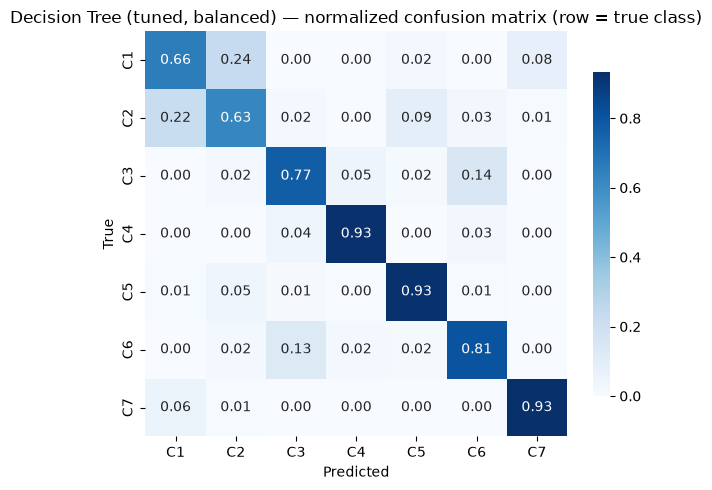

Best maxDepth: 20


In [22]:
dt_base = DecisionTreeClassifier(labelCol="label", featuresCol="features", seed=SEED)
dt_grid = (ParamGridBuilder()
           .addGrid(dt_base.maxDepth, [10, 15, 20])
           .build())
dt_cv = tune_model("Decision Tree (tuned, balanced)", dt_base, dt_grid, train_bal, test_df)
print("Best maxDepth:", dt_cv.bestModel.getMaxDepth())

[Random Forest (tuned, balanced)] tuned over 6 param combo(s) x 3 folds in 304.8s
Random Forest (tuned, balanced):  accuracy=0.7279   weighted_F1=0.7408   train_time=304.8s

    precision  recall     f1
C1      0.755   0.745  0.750
C2      0.855   0.672  0.753
C3      0.778   0.781  0.780
C4      0.456   0.975  0.621
C5      0.225   0.968  0.365
C6      0.525   0.860  0.652
C7      0.522   0.971  0.679


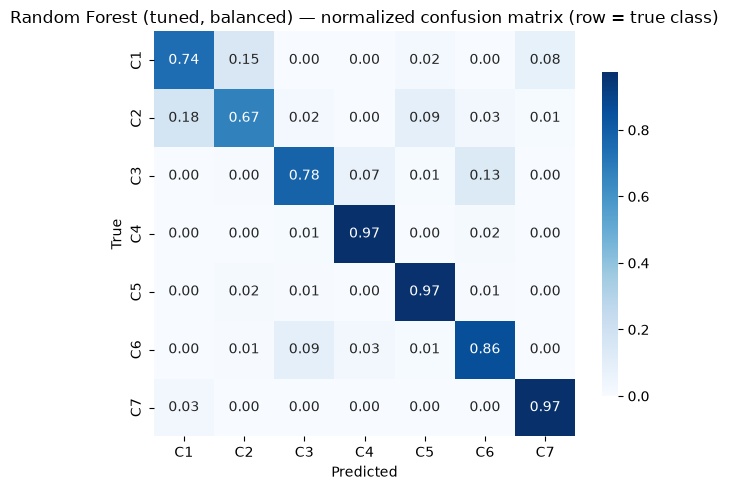

Best numTrees: 100  maxDepth: 25


In [23]:
rf_base = RandomForestClassifier(labelCol="label", featuresCol="features", seed=SEED)
rf_grid = (ParamGridBuilder()
           .addGrid(rf_base.numTrees, [50, 100])
           .addGrid(rf_base.maxDepth, [15, 20, 25])
           .build())
rf_cv = tune_model("Random Forest (tuned, balanced)", rf_base, rf_grid, train_bal, test_df)
print("Best numTrees:", rf_cv.bestModel.getNumTrees, " maxDepth:", rf_cv.bestModel.getMaxDepth())

[GBT (tuned, balanced)] tuned over 4 param combo(s) x 3 folds in 255.9s
GBT (tuned, balanced):  accuracy=0.6181   weighted_F1=0.6442   train_time=255.9s

    precision  recall     f1
C1      0.686   0.687  0.687
C2      0.819   0.513  0.631
C3      0.736   0.682  0.708
C4      0.400   0.964  0.565
C5      0.118   0.926  0.209
C6      0.406   0.764  0.531
C7      0.432   0.938  0.592


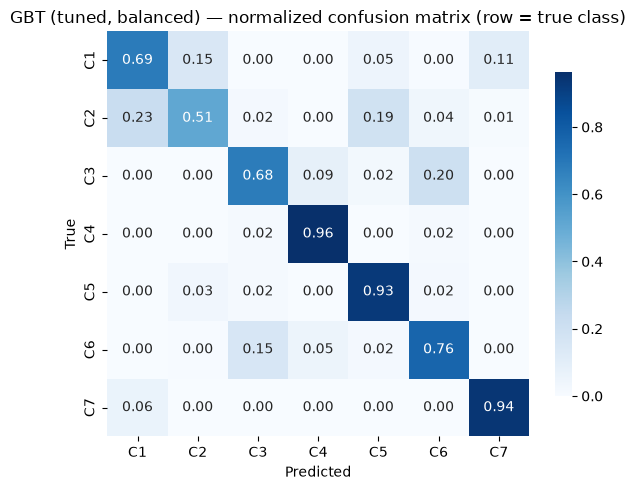

In [ ]:
gbt_base = GBTClassifier(labelCol="label", featuresCol="features", seed=SEED)
ovr_base = OneVsRest(classifier=gbt_base, labelCol="label", featuresCol="features")
gbt_grid = (ParamGridBuilder()
            .addGrid(gbt_base.maxDepth, [3, 5])
            .addGrid(gbt_base.maxIter, [10, 20])
            .build())
gbt_cv = tune_model("GBT (tuned, balanced)", ovr_base, gbt_grid, train_bal, test_df)

best_gbt = gbt_cv.bestModel.models[0]
print("Best GBT maxDepth:", best_gbt.getMaxDepth(), " maxIter:", best_gbt.getMaxIter())

[MLP (tuned, balanced)] tuned over 4 param combo(s) x 3 folds in 188.1s
MLP (tuned, balanced):  accuracy=0.7409   weighted_F1=0.7500   train_time=188.1s

    precision  recall     f1
C1      0.753   0.744  0.748
C2      0.839   0.696  0.761
C3      0.815   0.818  0.817
C4      0.569   0.951  0.712
C5      0.258   0.953  0.406
C6      0.551   0.859  0.671
C7      0.580   0.961  0.724


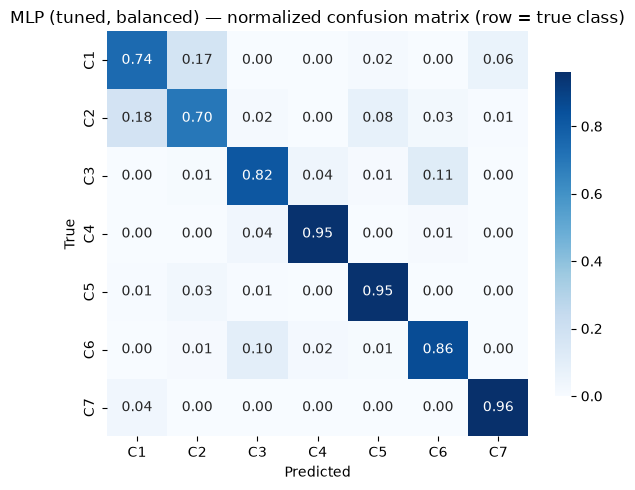

Best layers: [54, 128, 64, 7]  maxIter: 300


In [26]:
n_feat = len(FEATURE_COLS)
scaler_t = StandardScaler(inputCol="features", outputCol="scaledFeatures", withMean=True, withStd=True)
mlp_t = MultilayerPerceptronClassifier(labelCol="label", featuresCol="scaledFeatures", seed=SEED)
mlp_pipe_t = Pipeline(stages=[scaler_t, mlp_t])

mlp_grid = (ParamGridBuilder()
            .addGrid(mlp_t.layers, [[n_feat, 64, 32, 7], [n_feat, 128, 64, 7]])
            .addGrid(mlp_t.maxIter, [200, 300])
            .build())
mlp_cv = tune_model("MLP (tuned, balanced)", mlp_pipe_t, mlp_grid, train_bal, test_df)

best_mlp = mlp_cv.bestModel.stages[-1]
print("Best layers:", best_mlp.getLayers(), " maxIter:", best_mlp.getMaxIter())

## 9. Imbalanced training

Decision Tree (imbalanced):  accuracy=0.8544   weighted_F1=0.8524   train_time=3.1s

    precision  recall     f1
C1      0.868   0.827  0.847
C2      0.848   0.905  0.876
C3      0.869   0.828  0.848
C4      0.883   0.721  0.794
C5      0.828   0.390  0.530
C6      0.711   0.661  0.686
C7      0.902   0.874  0.888


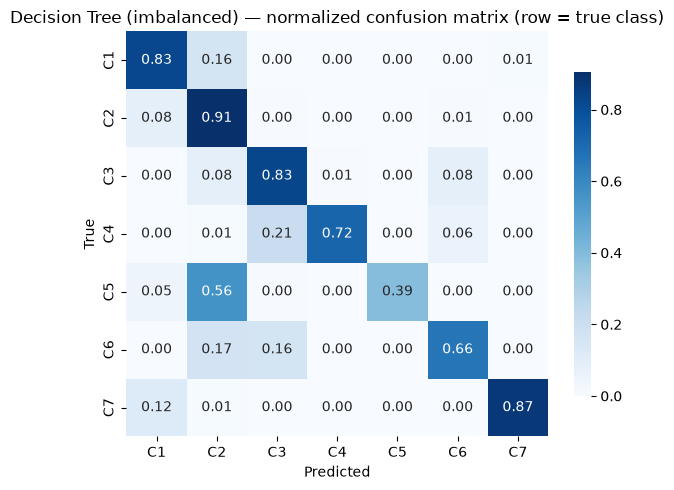

In [27]:
dt_imb = DecisionTreeClassifier(labelCol="label", featuresCol="features", maxDepth=15, seed=SEED)
_ = run_model("Decision Tree (imbalanced)", dt_imb, train_df, test_df)

Random Forest (imbalanced):  accuracy=0.7899   weighted_F1=0.7815   train_time=45.4s

    precision  recall     f1
C1      0.788   0.759  0.773
C2      0.787   0.860  0.822
C3      0.751   0.895  0.817
C4      0.896   0.587  0.709
C5      0.941   0.109  0.196
C6      0.882   0.315  0.465
C7      0.926   0.702  0.798


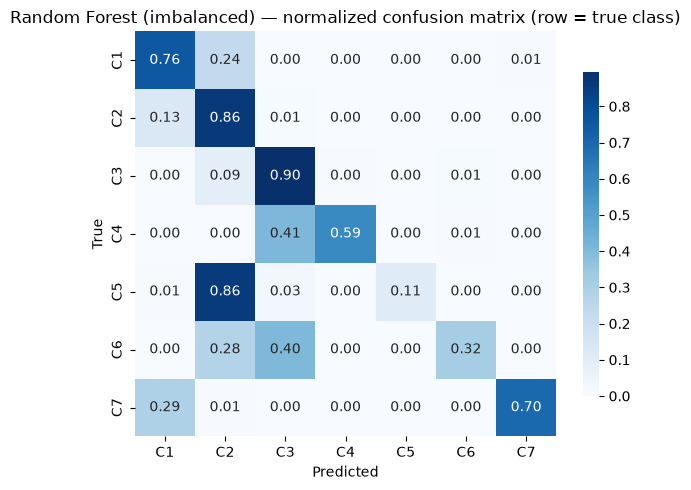

In [28]:
rf_imb = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=50, maxDepth=15, seed=SEED)
_ = run_model("Random Forest (imbalanced)", rf_imb, train_df, test_df)

GBT (imbalanced):  accuracy=0.7599   weighted_F1=0.7533   train_time=65.2s

    precision  recall     f1
C1      0.748   0.738  0.743
C2      0.774   0.822  0.797
C3      0.717   0.854  0.780
C4      0.823   0.654  0.729
C5      0.887   0.150  0.257
C6      0.581   0.319  0.412
C7      0.860   0.629  0.727


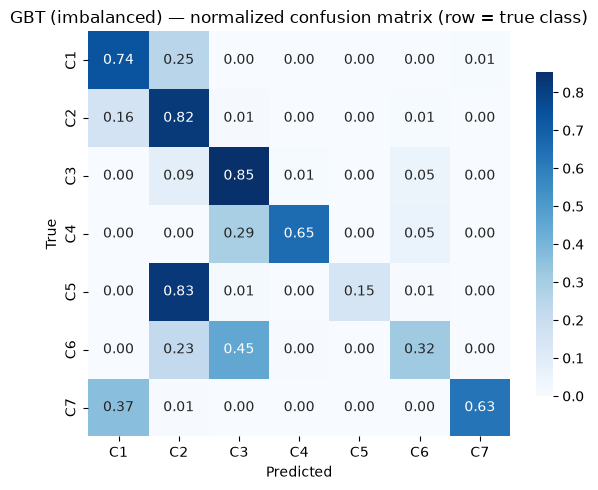

In [29]:
gbt_imb = GBTClassifier(labelCol="label", featuresCol="features", maxIter=20, maxDepth=5, seed=SEED)
ovr_gbt_imb = OneVsRest(classifier=gbt_imb, labelCol="label", featuresCol="features")
_ = run_model("GBT (imbalanced)", ovr_gbt_imb, train_df, test_df)

MLP (imbalanced):  accuracy=0.7841   weighted_F1=0.7793   train_time=20.1s

    precision  recall     f1
C1      0.792   0.754  0.772
C2      0.800   0.852  0.825
C3      0.717   0.820  0.765
C4      0.538   0.308  0.392
C5      0.687   0.218  0.331
C6      0.540   0.410  0.466
C7      0.804   0.731  0.766


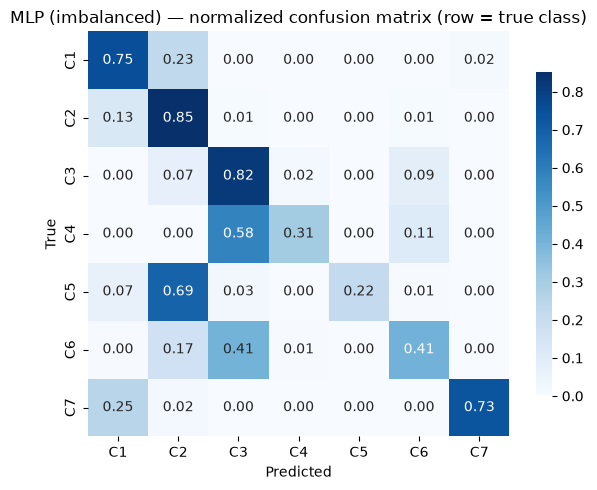

In [30]:
scaler_imb = StandardScaler(inputCol="features", outputCol="scaledFeatures", withMean=True, withStd=True)
mlp_imb = MultilayerPerceptronClassifier(labelCol="label", 
                                         featuresCol="scaledFeatures",
                                         layers=[len(FEATURE_COLS), 32, 7],
                                         maxIter=100, 
                                         seed=SEED)
mlp_pipeline_imb = Pipeline(stages=[scaler_imb, mlp_imb])
_ = run_model("MLP (imbalanced)", mlp_pipeline_imb, train_df, test_df)

In [31]:
summary_full = pd.DataFrame({
    name: {
        "accuracy":        round(r["accuracy"], 3),
        "weighted_F1":     round(r["weighted_f1"], 3),
        "macro_precision": round(r["per_class"]["precision"].mean(), 3),
        "macro_recall":    round(r["per_class"]["recall"].mean(), 3),
        "train_time_s":    round(r["train_time_s"], 1),
    }
    for name, r in RESULTS.items()
}).T.sort_index()

summary_full

,accuracy,weighted_F1,macro_precision,macro_recall,train_time_s
Decision Tree (balanced),0.665,0.678,0.565,0.804,2.7
Decision Tree (imbalanced),0.854,0.852,0.844,0.744,3.1
"Decision Tree (tuned, balanced)",0.670,0.681,0.569,0.807,12.7
GBT (balanced),0.618,0.644,0.514,0.782,42.1
GBT (imbalanced),0.760,0.753,0.770,0.595,65.2
"GBT (tuned, balanced)",0.618,0.644,0.514,0.782,255.9
MLP (balanced),0.664,0.681,0.529,0.784,7.0
MLP (imbalanced),0.784,0.779,0.697,0.585,20.1
"MLP (tuned, balanced)",0.741,0.750,0.624,0.855,188.1
Random Forest (balanced),0.687,0.706,0.561,0.829,9.0


## 10. Discussion and Conclusions

### Model comparison

Evaluated on the untouched, imbalanced test set, the **tuned MLP** is the best model
(weighted F1 = 0.750, macro-recall = 0.855), followed closely by the **tuned Random Forest**
(F1 = 0.741, macro-recall = 0.853). Both improved substantially once the tuning grids were
widened, and — importantly — gained on *both* axes: higher weighted F1 *and* higher macro-recall,
i.e. more accurate **and** more balanced across classes. The MLP result is consistent with
Blackard & Dean (1999), whose strongest model was also a feed-forward network.

Tree models without tuning are robust but limited: Decision Tree and Random Forest baselines
sit at F1 ≈ 0.68–0.71. Tuning barely moved the single Decision Tree (F1 0.678 → 0.681), as
expected for a model insensitive to most hyperparameters. **GBT, wrapped in OneVsRest, is the
weakest and slowest model**: Spark's `GBTClassifier` is binary-only, so OneVsRest trains seven
GBTs per fit, and cross-validation reselected the baseline parameters (maxDepth=5, maxIter=20)
for no gain over 256 s of tuning. This makes GBT-via-OneVsRest a poor fit for this multiclass
problem compared to the natively-multiclass alternatives.

A note on tuning: even after widening the grids, cross-validation still selected the maximum
grid values for MLP (`[54,128,64,7]`, 300 iterations) and Random Forest (100 trees, depth 25).
This boundary hit indicates that larger configurations might improve performance further, but
with diminishing returns and rising cost (RF tuning already ~5 min on a 2-node cluster). We
stopped at a reasonable performance/time trade-off rather than chasing marginal gains.

### The effect of class balancing

Training on the **full imbalanced** set versus the **undersampled balanced** set reveals a
systematic trade-off, visible across every model in the summary table:

- **Imbalanced training raises overall accuracy** (e.g. Decision Tree 0.665 → 0.854) but
  **collapses minority-class recall** (macro-recall 0.804 → 0.744, and far worse for the rarest
  classes).
- **Balanced training does the opposite**: lower accuracy, but much higher macro-recall
  (Random Forest reaches 0.853 macro-recall balanced vs 0.604 imbalanced).

The reason is structural, not a tuning artifact: trained on real frequencies, a model
over-predicts the dominant classes (which form ~85% of the data) and learns to ignore the rare
ones; trained on a balanced set, it treats all classes as equally likely. The Decision Tree
(imbalanced) is the clearest cautionary example — it has the **highest accuracy in the whole
study (0.854)** yet is among the least equitable across classes. This is precisely why we report
per-class metrics and macro-averages rather than accuracy alone: overall accuracy hides which
classes are being sacrificed. Undersampling is the right choice when minority classes matter —
as they often do in ecological cover-type mapping, where rare species are frequently the ones
of interest.

### Comparison with the literature

Our best weighted F1 (≈0.75) is below the 0.97 reported by Tavakol Sadrabadi & Innocente (2023).
The gap is fully explained by two deliberate scope choices: aggressive undersampling to ~15k
training rows (vs. their full ~575k) and modest tuning grids suited to a 2-node cluster. On
minority-class recall, however, our balanced models perform *better*, a direct consequence of
the balanced training set. Two findings also led us to revise claims from the literature:

- **Imbalance ratio:** we measured Nmax/Nmin ≈ **103:1** (class 2 vs class 4) on the full
  dataset, not the 77:1 reported in the literature, which uses class 1 as the numerator.
- **Hillshade collinearity:** the literature reports r ≈ +0.98 between Hillshade_9am and
  Hillshade_3pm; on the full raw dataset we measured **r = −0.78** — strong but *negative*
  (complementary, not redundant). Combined with three of four models being tree-based, this is
  why we kept all 54 features.

### Distributed setup

The pipeline runs on Spark MLlib over a Hadoop cluster (HDFS storage, YARN resource management,
Spark in client mode), on a 2-node topology (1 master + 1 worker). The 2-node choice was driven
by the RAM budget: with limited total memory, every additional node pays a fixed OS+daemon
reservation, so spreading across three nodes would have left containers too small to host
healthy executors. Concentrating memory on one robust worker, while keeping the master/worker
separation of a real cluster, was the better trade-off for this hardware — and the small dataset
would not have benefited from additional parallelism anyway. Training times (from ~3 s for a
Decision Tree to ~256 s for tuned GBT-OneVsRest) show where the OneVsRest overhead dominates.

### Limitations and future work

- **Aggressive undersampling caps overall accuracy** by discarding most majority-class data.
  A **partial undersampling** scheme — capping large classes at an intermediate threshold rather
  than reducing to the smallest class — would be a natural next experiment: a third point between
  the two regimes we tested, likely improving accuracy while preserving acceptable minority recall.
- **Tuning grids remain bounded** by compute; the persistent boundary hit suggests larger grids
  (or more cluster nodes) could yield further gains.
- Per-class confusions concentrate among ecologically adjacent cover types (e.g. Spruce/Fir vs
  Lodgepole Pine), consistent with Blackard & Dean (1999).

### Conclusion

We built a complete, reproducible Spark MLlib classification pipeline on a real Hadoop/YARN/HDFS
cluster, comparing four model families under tuning and under two class-balancing regimes. The
tuned MLP performed best. The central finding is methodological rather than a single accuracy
number: on a severely imbalanced dataset, the choice of class-balancing strategy governs a
direct trade-off between overall accuracy and minority-class recall, which only per-class and
macro-averaged metrics make visible.